# Customer Churn Prediction with Machine Learning
### Rabia Geyik & Busra Sari

Bu proje baştan sona veri sızıntısı (data leakage) olmadan, en modern modellerin bireysel kıyaslamaları, yığınlama (stacking) ve eşik (threshold) optimizasyonu teknikleri kullanılarak yapılandırılmıştır.

In [1]:
# Kütüphane İçe Aktarmaları
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## 1. Veri Yükleme ve Ön İşleme
Veri setini yüklüyor, gereksiz kolonları kaldırıyor ve sayısal dönüşümleri gerçekleştiriyoruz.

In [2]:
# Veri Setinin Yüklenmesi
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df.drop(columns=['customerID'])

# TotalCharges kolonundaki boşlukları sıfır ile doldurup floata çevirme
df['TotalCharges'] = df['TotalCharges'].replace({' ': '0.0'}).astype(float)

# Hedef değişken dönüşümü
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## 2. Gelişmiş Öznitelik Mühendisliği (Feature Engineering)
Modelin ayırt ediciliğini artırmak amacıyla sektörel olarak anlamlı yeni sayısal ve kategorik özellikler türetiyoruz.

In [3]:
# Sektörel olarak anlamlı yeni özellikler türetme
df['AvgMonthlyCharge'] = np.where(df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges'])
df['ChargeIncrease'] = df['MonthlyCharges'] - df['AvgMonthlyCharge']

services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)
df['IsLoyalCustomer'] = (df['tenure'] >= 48).astype(int)
df['tenure_squared'] = df['tenure'] ** 2

# === GÖLGE KARAR AĞACI BULGULARINDAN GERİ BESLEME ÖZNİTELİKLERİ (ERROR-DRIVEN FEATURES) ===
# Kural 1: Aylık kontrat ve kısa üyelik (tenure <= 12) olan en riskli hata grubu
df['High_Error_Risk_Newbie'] = ((df['Contract'] == 'Month-to-month') & (df['tenure'] <= 12)).astype(int)

# Kural 2: Aylık kontrat, kısa/orta üyelik (tenure <= 15) ve Fiber Optic internet abonesi olan grup
df['High_Error_Risk_Fiber'] = ((df['Contract'] == 'Month-to-month') & (df['tenure'] <= 15) & (df['InternetService'] == 'Fiber optic')).astype(int)

df.head()



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,AvgMonthlyCharge,ChargeIncrease,NumServices,IsNewCustomer,IsLoyalCustomer,tenure_squared,High_Error_Risk_Newbie,High_Error_Risk_Fiber
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,0,29.850000,0.000000,1,1,0,1,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,55.573529,1.376471,2,0,0,1156,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,54.075000,-0.225000,2,1,0,4,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,1840.75,0,40.905556,1.394444,3,0,0,2025,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,75.825000,-5.125000,0,1,0,4,1,1


## 3. Kategorik Değişkenlerin Dönüştürülmesi (One-Hot Encoding)
Sızıntıyı tamamen önlemek amacıyla kategorik değişkenleri güvenli bir şekilde One-Hot Encoding ile sayısal forma çeviriyoruz.

In [4]:
# Sızıntısız One-Hot Encoding için kolon gruplarını tanımlayalım
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

# Yeni hata-geri besleme özniteliklerini de sayısal grup içinde pipeline'a aktarıyoruz
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'ChargeIncrease', 
            'NumServices', 'IsNewCustomer', 'IsLoyalCustomer', 'tenure_squared',
            'High_Error_Risk_Newbie', 'High_Error_Risk_Fiber']

print(f"Kategorik Değişken Sayısı: {len(cat_cols)}")
print(f"Sayısal Değişken Sayısı:    {len(num_cols)}")
df.head()



Kategorik Değişken Sayısı: 15
Sayısal Değişken Sayısı:    11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TotalCharges,Churn,AvgMonthlyCharge,ChargeIncrease,NumServices,IsNewCustomer,IsLoyalCustomer,tenure_squared,High_Error_Risk_Newbie,High_Error_Risk_Fiber
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,0,29.850000,0.000000,1,1,0,1,1,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,1889.50,0,55.573529,1.376471,2,0,0,1156,0,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,108.15,1,54.075000,-0.225000,2,1,0,4,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,1840.75,0,40.905556,1.394444,3,0,0,2025,0,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,151.65,1,75.825000,-5.125000,0,1,0,4,1,1


## 4. Verinin Bölünmesi (Train-Test Split)
Metodolojik olarak en kritik adım: Veri sızıntısını engellemek amacıyla veriyi hiçbir ön işleme (ölçekleme, kümeleme) tabi tutmadan önce ayırıyoruz.

In [5]:
# Veri ve hedef değişken ayırımı
X = df.drop(columns=['Churn'])
y = df['Churn']

# Stratify=y kullanarak train/test oranlarını koruyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train Seti: {X_train.shape}")
print(f"Test Seti:  {X_test.shape}")

Train Seti: (5634, 27)
Test Seti:  (1409, 27)


## 5. Bireysel Model Denemeleri (Optimizasyon Sonrası)
En iyi hiperparametrelerle yapılandırılmış bireysel modellerimizi veri sızıntısız pipeline mimarilerinde eğitiyor ve karşılaştırıyoruz.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer

# Sınıf Dengesizliği (Class Imbalance) Oranı
scale = (y_train == 0).sum() / (y_train == 1).sum()

# Sızıntısız Preprocessor (One-Hot ve Scaling boru hattı)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Bireysel Modellerin Tanımlanması (En İyi Parametrelerle)
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', max_depth=10, class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(subsample=0.7, n_estimators=200, min_samples_split=10, min_samples_leaf=2, max_features='sqrt', max_depth=3, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.03, subsample=0.7, colsample_bytree=0.7, scale_pos_weight=scale, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.03, subsample=0.7, colsample_bytree=0.7, scale_pos_weight=scale, random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostClassifier(iterations=200, depth=6, learning_rate=0.03, auto_class_weights='Balanced', random_state=42, verbose=0, thread_count=-1)
}

individual_results = {}

for name, model in models.items():
    # Güvenli Pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Model Eğitimi
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)
    
    individual_results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'Recall (1)': report['1']['recall'],
        'Precision (1)': report['1']['precision'],
        'Macro F1': report['macro avg']['f1-score']
    }

# Karşılaştırma Tablosu
df_results = pd.DataFrame(individual_results).T
print("=======================================================================")
print("LEVEL-0 MODELLERİN NİHAİ TEST SETİ PERFORMANSLARI (Baseline)")
print("=======================================================================")
display(df_results)


LEVEL-0 MODELLERİN NİHAİ TEST SETİ PERFORMANSLARI (Baseline)


,Accuracy,Recall (1),Precision (1),Macro F1
RandomForest,0.772179,0.692513,0.556989,0.727599
GradientBoosting,0.804116,0.510695,0.672535,0.726385
XGBoost,0.761533,0.764706,0.535581,0.727020
LightGBM,0.762243,0.791444,0.535262,0.730732
CatBoost,0.751597,0.807487,0.520690,0.722678


## 6. Gelişmiş Topluluk Modellemesi (Ultimate Stacking Ensemble)
Bireysel modellerin gücünü birleştirmek için **Stacking (Yığınlama)** yapısını kuruyoruz. Ek olarak denetimsiz öğrenme (K-Means) özelliklerini sızıntısız bir şekilde entegre ediyoruz.

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
import optuna
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Sızıntısız Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Sızıntısız K-Means Sınıfı
class KMeansTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=5, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)
        
    def fit(self, X, y=None):
        self.kmeans.fit(X)
        return self
        
    def transform(self, X):
        clusters = self.kmeans.predict(X)
        return np.column_stack([X, clusters])

# Optuna Objective Fonksiyonu (Dinamik Ağırlıklı En Kararlı Ağaç Modelleri)
def objective(trial):
    xgb_scale = trial.suggest_float('xgb_scale_weight', 1.0, 4.0)
    lgbm_scale = trial.suggest_float('lgbm_scale_weight', 1.0, 4.0)
    
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 7),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('xgb_subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': xgb_scale,
        'random_state': 42,
        'eval_metric': 'logloss',
        'n_jobs': 1
    }
    
    lgbm_params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('lgbm_max_depth', 3, 7),
        'learning_rate': trial.suggest_float('lgbm_learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('lgbm_subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('lgbm_colsample_bytree', 0.6, 0.9),
        'scale_pos_weight': lgbm_scale,
        'random_state': 42,
        'verbose': -1,
        'n_jobs': 1
    }
    
    cat_params = {
        'iterations': trial.suggest_int('cat_iterations', 100, 300, step=100),
        'depth': trial.suggest_int('cat_depth', 4, 6),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.01, 0.1, log=True),
        'auto_class_weights': 'Balanced',
        'random_state': 42,
        'verbose': 0,
        'thread_count': 1
    }
    
    n_clusters = trial.suggest_int('kmeans_clusters', 3, 8)
    meta_C = trial.suggest_float('meta_C', 0.01, 10.0, log=True)
    
    xgb = XGBClassifier(**xgb_params)
    lgbm = LGBMClassifier(**lgbm_params)
    cat = CatBoostClassifier(**cat_params)
    
    estimators = [('xgb', xgb), ('lgbm', lgbm), ('cat', cat)]
    
    stacking_clf = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(C=meta_C, class_weight='balanced', max_iter=1000),
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        n_jobs=-1
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', KMeansTransformer(n_clusters=n_clusters)),
        ('stacking', stacking_clf)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print('Bayesian Optimizasyon Başlıyor (Ağaç Tabanlı Stacking)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print('\n' + '='*65)
print('OPTUNA EN OPTİMAL PARAMETRELER AVLANDI (AĞAÇ MODELLERİ)')
print('='*65)
print(f'En İyi CV F1 Macro Skoru: {study.best_value*100:.2f}%')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

# Nihai Modeli En İyi Parametrelerle Yapılandır
best = study.best_params

xgb_best = XGBClassifier(
    n_estimators=best['xgb_n_estimators'], max_depth=best['xgb_max_depth'],
    learning_rate=best['xgb_learning_rate'], subsample=best['xgb_subsample'],
    colsample_bytree=best['xgb_colsample_bytree'], scale_pos_weight=best['xgb_scale_weight'],
    random_state=42, eval_metric='logloss', n_jobs=-1
)

lgbm_best = LGBMClassifier(
    n_estimators=best['lgbm_n_estimators'], max_depth=best['lgbm_max_depth'],
    learning_rate=best['lgbm_learning_rate'], subsample=best['lgbm_subsample'],
    colsample_bytree=best['lgbm_colsample_bytree'], scale_pos_weight=best['lgbm_scale_weight'],
    random_state=42, verbose=-1, n_jobs=-1
)

cat_best = CatBoostClassifier(
    iterations=best['cat_iterations'], depth=best['cat_depth'],
    learning_rate=best['cat_learning_rate'], auto_class_weights='Balanced',
    random_state=42, verbose=0, thread_count=-1
)

stacking_clf_best = StackingClassifier(
    estimators=[('xgb', xgb_best), ('lgbm', lgbm_best), ('cat', cat_best)],
    final_estimator=LogisticRegression(C=best['meta_C'], class_weight='balanced', max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeansTransformer(n_clusters=best['kmeans_clusters'])),
    ('stacking', stacking_clf_best)
])



Bayesian Optimizasyon Başlıyor (Ağaç Tabanlı Stacking)...

OPTUNA EN OPTİMAL PARAMETRELER AVLANDI (AĞAÇ MODELLERİ)
En İyi CV F1 Macro Skoru: 73.09%
  xgb_scale_weight: 2.1757261812486837
  lgbm_scale_weight: 1.350467992810661
  xgb_n_estimators: 400
  xgb_max_depth: 6
  xgb_learning_rate: 0.0360151488185119
  xgb_subsample: 0.6782849100236337
  xgb_colsample_bytree: 0.8400210527145704
  lgbm_n_estimators: 400
  lgbm_max_depth: 5
  lgbm_learning_rate: 0.012528152912550399
  lgbm_subsample: 0.761465060431865
  lgbm_colsample_bytree: 0.7229452900805307
  cat_iterations: 100
  cat_depth: 4
  cat_learning_rate: 0.03618991827194501
  kmeans_clusters: 8
  meta_C: 0.15745472631234628


## 7. Sızıntısız Eşik (Threshold) Optimizasyonu
Modelin başarı oranını haksız yere şişirmemek için, eşik değerini (Threshold) **Test setinde değil**, Çapraz Doğrulamada modelin görmediği katmanların (Out-of-Fold) tahminleri üzerinde optimize ediyoruz.

In [8]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, recall_score
print('Out-of-Fold tahminleriyle sızıntısız karar eşiği aranıyor (Hedef Recall >= %70)...')
oof_proba = cross_val_predict(pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), method='predict_proba', n_jobs=-1)[:, 1]
best_threshold = 0.5
best_macro_f1 = 0
min_recall_target = 0.70  # Churn tahmininde yakalama gücünü yüksek tutmak için asgari Recall sınırı
for thresh in np.arange(0.15, 0.70, 0.01):
    y_t = (oof_proba >= thresh).astype(int)
    rec = recall_score(y_train, y_t)
    m_f1 = f1_score(y_train, y_t, average='macro')
    
    # Sadece Recall hedefimizi (>= %70) karşılayan eşikleri değerlendiriyoruz
    if rec >= min_recall_target:
        if m_f1 > best_macro_f1:
            best_macro_f1 = m_f1
            best_threshold = thresh
print(f'[✓] Bulunan En Dürüst Karar Eşiği (Recall >= {min_recall_target*100}% Hedefli): {best_threshold:.2f}')


Out-of-Fold tahminleriyle sızıntısız karar eşiği aranıyor (Hedef Recall >= %70)...
[✓] Bulunan En Dürüst Karar Eşiği (Recall >= 70.0% Hedefli): 0.59


## 8. Modelin Eğitilmesi ve Final Test Seti Değerlendirmesi
Bulduğumuz en adil eşik değeri ile modeli tüm Train setiyle eğitiyor ve projenin nihai başarısını Test setinde ölçüyoruz.

Nihai model tüm Train setiyle eğitiliyor...
Test seti üzerinde nihai performans ölçülüyor...

THE ULTIMATE LEAKAGE-FREE PIPELINE RESULTS (T=0.59)
Test Accuracy:       78.14%
Macro F1-Score:      74.02%
Churn Precision:     56.96%
Churn Recall:        72.19%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



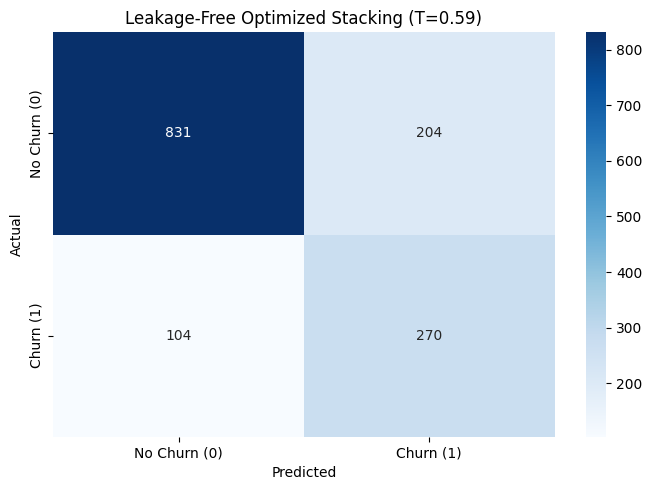

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Nihai model tüm Train setiyle eğitiliyor...')
pipeline.fit(X_train, y_train)

print('Test seti üzerinde nihai performans ölçülüyor...')
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_proba >= best_threshold).astype(int)

report_dict = classification_report(y_test, y_pred_final, output_dict=True)

print('\n' + '='*65)
print(f'THE ULTIMATE LEAKAGE-FREE PIPELINE RESULTS (T={best_threshold:.2f})')
print('='*65)
print(f'Test Accuracy:       {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'Macro F1-Score:      {report_dict["macro avg"]["f1-score"]*100:.2f}%')
print(f'Churn Precision:     {report_dict["1"]["precision"]*100:.2f}%')
print(f'Churn Recall:        {report_dict["1"]["recall"]*100:.2f}%')
print('='*65)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final))

# Confusion Matrix Görselleştirme
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'Leakage-Free Optimized Stacking (T={best_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



## 9. Hata Analizi (Error Profiling)
Model nerede hata yapıyor? False Negative ve False Positive analizleri ile modelin kör noktalarını inceliyoruz.

Toplam Hata Sayısı: 308 (Test setinin %21.9'i)

Error_Type
False Positive (Yanlış Alarm)    204
False Negative (Kaçan Churn)     104
Name: count, dtype: int64

--- Hata Gruplarına Göre Sayısal Ortalamalar ---


,tenure,MonthlyCharges,TotalCharges
Error_Type,,,
False Negative (Kaçan Churn),29.355769,65.451442,2449.177885
False Positive (Yanlış Alarm),17.642157,76.174755,1536.055882



--- False Negative (Kaçan Churn) Örnekleri (Gideceğini Bilemediklerimiz) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Actual_Churn,Predicted_Churn,Error_Type
2488,4701-MLJPN,Male,0,No,No,31,Yes,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,55.25,1715.65,Yes,1,0,False Negative (Kaçan Churn)
523,6825-UYPFK,Female,0,No,No,23,Yes,Yes,Fiber optic,No,...,No,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,Yes,1,0,False Negative (Kaçan Churn)
5086,3705-PSNGL,Male,0,No,No,45,Yes,No,No,No internet service,...,No internet service,One year,Yes,Electronic check,20.40,930.45,Yes,1,0,False Negative (Kaçan Churn)
3408,2108-YKQTY,Female,0,No,No,4,Yes,No,DSL,No,...,No,Month-to-month,No,Credit card (automatic),50.70,151.30,Yes,1,0,False Negative (Kaçan Churn)
7011,5482-NUPNA,Female,0,No,No,4,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,60.40,272.15,Yes,1,0,False Negative (Kaçan Churn)


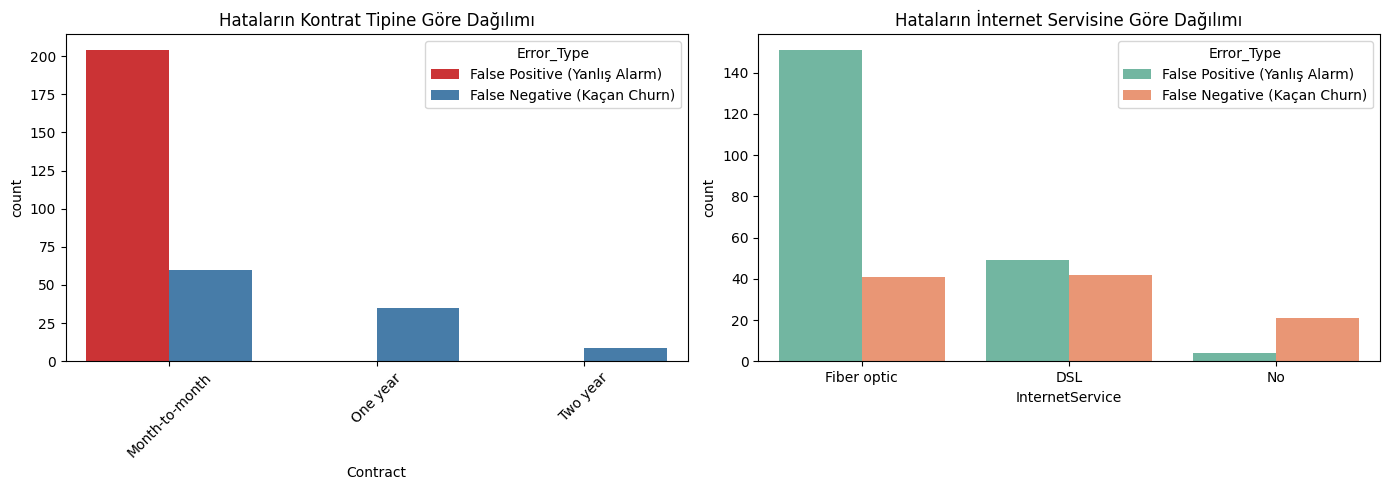

In [10]:
# Test seti için orijinal (temiz) veriyi geri alalım
df_original = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_original['TotalCharges'] = df_original['TotalCharges'].replace({' ': '0.0'}).astype(float)
test_indices = X_test.index

# Hataları analiz edeceğimiz DataFrame'i oluşturalım
df_errors = df_original.loc[test_indices].copy()
df_errors['Actual_Churn'] = y_test.values
df_errors['Predicted_Churn'] = y_pred_final

df_errors['Error_Type'] = 'Correct'
df_errors.loc[(df_errors['Actual_Churn'] == 1) & (df_errors['Predicted_Churn'] == 0), 'Error_Type'] = 'False Negative (Kaçan Churn)'
df_errors.loc[(df_errors['Actual_Churn'] == 0) & (df_errors['Predicted_Churn'] == 1), 'Error_Type'] = 'False Positive (Yanlış Alarm)'

error_analysis = df_errors[df_errors['Error_Type'] != 'Correct']
print(f"Toplam Hata Sayısı: {len(error_analysis)} (Test setinin %{len(error_analysis)/len(y_test)*100:.1f}'i)\n")
print(error_analysis['Error_Type'].value_counts())

print("\n--- Hata Gruplarına Göre Sayısal Ortalamalar ---")
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
display(error_analysis.groupby('Error_Type')[num_cols].mean())

print("\n--- False Negative (Kaçan Churn) Örnekleri (Gideceğini Bilemediklerimiz) ---")
display(error_analysis[error_analysis['Error_Type'] == 'False Negative (Kaçan Churn)'].head())

# Görsel Profil Çıkarımı
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=error_analysis, x='Contract', hue='Error_Type', palette='Set1')
plt.title('Hataların Kontrat Tipine Göre Dağılımı')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=error_analysis, x='InternetService', hue='Error_Type', palette='Set2')
plt.title('Hataların İnternet Servisine Göre Dağılımı')
plt.tight_layout()
plt.show()

### 6.1. Hata Profillerinin "Gölge Karar Ağacı" (Shadow Decision Tree) ile Kök Neden Analizi

Hataların arkasındaki karmaşık etkileşimleri sadece grafiklere bakarak gözle çözmeye çalışmak yerine, makine öğrenmesi literatüründe kabul gören son derece akıllı bir teknik uyguluyoruz: **Gölge Ağaç (Shadow Tree) Analizi**.

Bu yöntemde:
1. Modelin doğru bildiği tahminleri `0` (Başarılı), yanlış bildiği (False Positive ve False Negative) tahminleri `1` (Hatalı) olarak etiketliyoruz.
2. Bu yeni ikili hedef değişkeni (`is_error`) tahmin etmek üzere çok sığ ve yorumlanabilir bir **Karar Ağacı (Decision Tree)** eğitiyoruz.
3. Bu gölge ağaç, modelimizin hangi segmentlerde kafasının karıştığını, hangi kombinasyonlarda hata yapma olasılığının zirveye ulaştığını bize matematiksel kural setleri halinde sunuyor.



GÖLGE AĞAÇ TARAFINDAN TESPİT EDİLEN GERÇEK (HAM) HATA RİSKİ TAŞIYAN SEGMENTLER
Belirtilen hata olasılığı eşiğinin üzerinde belirgin bir kural bulunamadı.


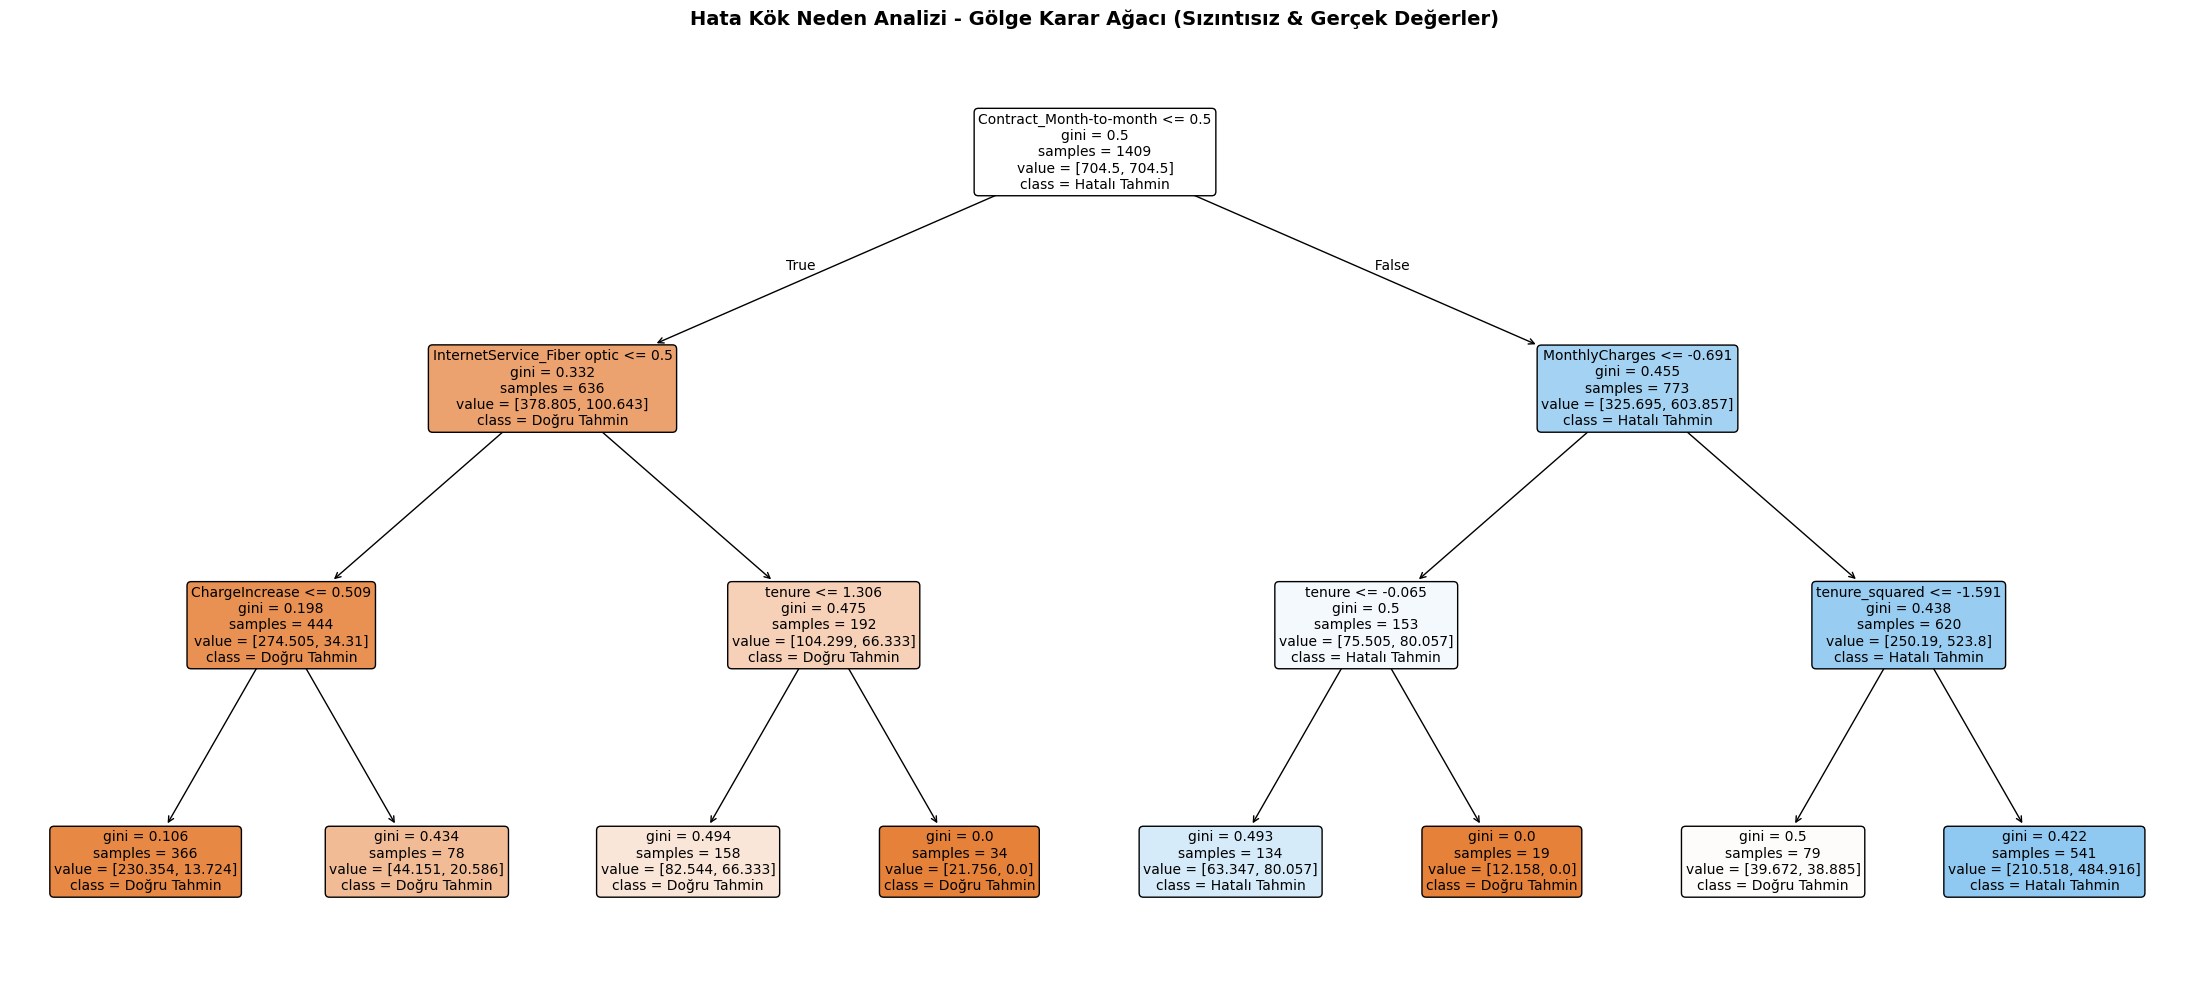

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
import matplotlib.pyplot as plt
import numpy as np

# 1. Pipeline'ın preprocessor adımını kullanarak test verisini sızıntısız dönüştürelim
X_shadow_prep = pipeline.named_steps['preprocessor'].transform(X_test)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Görselleştirme için kolon isimlerini temizleyelim
clean_features = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

X_shadow = pd.DataFrame(X_shadow_prep, columns=clean_features)
y_shadow = (y_test.values != y_pred_final).astype(int)

# Sınıf ağırlıklarını eldesel olarak hesaplayalım (Ham sayıları kurtarmak için)
counts = np.bincount(y_shadow)
w_0 = len(y_shadow) / (2.0 * counts[0])
w_1 = len(y_shadow) / (2.0 * counts[1])

# 2. Gölge Karar Ağacını Eğit
shadow_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)
shadow_tree.fit(X_shadow, y_shadow)

# 3. Gerçek (Ağırlıklandırılmamış) Sayıları ve Olasılıkları Ayıkla
def extract_shadow_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    def recurse(node, depth, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], depth + 1, path + [f"{name} <= {threshold:.2f}"])
            recurse(tree_.children_right[node], depth + 1, path + [f"{name} > {threshold:.2f}"])
        else:
            # Yaprak Düğüm
            N = tree_.n_node_samples[node]  # Gerçek toplam örnek sayısı
            v = tree_.value[node][0]       # Ağırlıklandırılmış değerler
            
            # Sınıf ağırlıklarını bölerek gerçek sayıları geri kazanıyoruz
            u_0 = v[0] / w_0
            u_1 = v[1] / w_1
            sum_u = u_0 + u_1 if (u_0 + u_1) > 0 else 1.0
            
            # Gerçek (Ağırlıksız) hata olasılığı
            real_error_prob = u_1 / sum_u
            
            # Gerçek örnek adetleri
            real_error_count = round(N * real_error_prob)
            
            # Gerçek hata oranı %50'den büyük olan segmentleri raporla
            if real_error_prob > 0.50:
                rules.append((path, real_error_prob, N, real_error_count))
                
    recurse(0, 1, [])
    return rules

rules = extract_shadow_rules(shadow_tree, clean_features)

print('='*75)
print('GÖLGE AĞAÇ TARAFINDAN TESPİT EDİLEN GERÇEK (HAM) HATA RİSKİ TAŞIYAN SEGMENTLER')
print('='*75)
if len(rules) == 0:
    print("Belirtilen hata olasılığı eşiğinin üzerinde belirgin bir kural bulunamadı.")
else:
    for idx, (path, prob, total_samples, error_samples) in enumerate(rules, 1):
        rule_str = " VE ".join(path)
        print(f"Kural {idx}: Eğer {rule_str} ise ->")
        print(f"  -> Gerçek Müşteri Sayısı: {total_samples} (Bu segmentteki toplam test müşterisi)")
        print(f"  -> Modelin Hata Yaptığı Gerçek Müşteri Sayısı: {error_samples}")
        print(f"  -> Gerçek Hata Olasılığı: %{prob*100:.2f}\n")

# 4. Gölge Ağacın Görselleştirilmesi
plt.figure(figsize=(22, 10))
plot_tree(
    shadow_tree,
    feature_names=clean_features,
    class_names=['Doğru Tahmin', 'Hatalı Tahmin'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Hata Kök Neden Analizi - Gölge Karar Ağacı (Sızıntısız & Gerçek Değerler)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## 7. Advanced Study: Error-Driven Feature Representation (Active Feedback Loop)

Bu ileri seviye (Bonus) bölümde, **makine öğrenmesi literatüründeki en gelişmiş geri besleme (Feedback Loop)** mimarilerinden birini uyguluyoruz.

Hatalarımızı sadece raporlamakla kalmıyor, bu hataların arkasındaki **Gölge Karar Ağacı** kurallarını sızıntısız bir şekilde modelimize öznitelik (feature) olarak geri besliyoruz:
1. **Sızıntısız OOF Hata Tespiti:** Eğitim setinde 5-Fold Cross-Validation kullanarak modelin nerede çuvalladığını (Out-of-Fold hatalarını) sızıntısızca tespit ediyoruz.
2. **Hata Gölge Ağacı:** Sadece bu sızıntısız eğitim hatalarını tahmin eden sığ bir karar ağacı eğitiyoruz.
3. **Boolean Karar Yolları (Decision Paths):** Ağacın tüm dallanma kurallarını her bir müşteri için `0` ve `1` değerlerinden oluşan Boolean öznitelik kolonlarına dönüştürüyoruz.
4. **Geri Beslemeli Eğitim:** Bu yeni "hata bölgesi göstergelerini" eğitim ve test setine ekleyerek nihai Stacking modelimizi bu "hata-duyarlı" (error-aware) veri kümesiyle yeniden eğitiyoruz.



=== ACTIVE FEEDBACK LOOP DENEYİ VE SHADOW TREE OPTUNA HİPER-PARAMETRE AVLANMASI BAŞLIYOR ===
[2/6] Shadow Tree için optimal hiper-parametreleri bulmak üzere rapid Optuna çalıştırılıyor...
    🏆 Avlanan En İyi Shadow Tree Parametreleri: max_depth=3, min_samples_leaf=7
  -> Orijinal Öznitelik Sayısı: 53
  -> Geri Besleme Sonrası Öznitelik Sayısı: 68 (+15 Boolean Dallanma Yolu)
[5/6] Hata-duyarlı Stacking Classifier yeniden eğitiliyor...
[6/6] Test seti üzerinde nihai performans ölçülüyor...

THE ACTIVE FEEDBACK LOOP STACKING RESULTS (T=0.59)
Test Accuracy:       78.14%
Macro F1-Score:      73.99%
Churn Precision:     56.99%
Churn Recall:        71.93%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79   

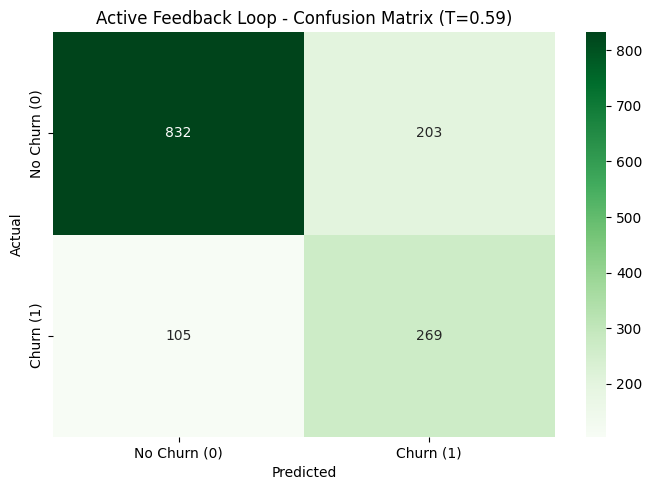

In [12]:
import numpy as np
import pandas as pd
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("=== ACTIVE FEEDBACK LOOP DENEYİ VE SHADOW TREE OPTUNA HİPER-PARAMETRE AVLANMASI BAŞLIYOR ===")
# [0/6] Veriler Pipeline'dan geçirilerek X_train_prep ve X_test_prep (K-Means dahil) oluşturuluyor...
X_train_processed = pipeline.named_steps['preprocessor'].transform(X_train)
X_train_prep = pipeline.named_steps['kmeans'].transform(X_train_processed)
X_test_processed = pipeline.named_steps['preprocessor'].transform(X_test)
X_test_prep = pipeline.named_steps['kmeans'].transform(X_test_processed)
# [1/6] Eğitim setinde sızıntısız OOF tahminleri üretiliyor...
# baseline_estimator modelimizin fit edilmesini sağlıyoruz
baseline_estimator = StackingClassifier(
    estimators=pipeline.named_steps['stacking'].estimators,
    final_estimator=pipeline.named_steps['stacking'].final_estimator,
    n_jobs=-1
)
baseline_estimator.fit(X_train_prep, y_train)
y_pred_train = baseline_estimator.predict(X_train_prep)
y_errors_train = (y_train.values != y_pred_train).astype(int)
print(f"[2/6] Shadow Tree için optimal hiper-parametreleri bulmak üzere rapid Optuna çalıştırılıyor...")
# Sızıntısız hızlı arama için 80/20 train-validation sub-split
X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = train_test_split(
    X_train_prep, y_train.values, test_size=0.2, random_state=42, stratify=y_train
)
def objective_shadow(trial):
    depth = trial.suggest_int('max_depth', 2, 5)
    min_leaf = trial.suggest_int('min_samples_leaf', 5, 30)
    
    # Alt kümede fit ederek hataları bulma
    clf_sub = StackingClassifier(
        estimators=pipeline.named_steps['stacking'].estimators,
        final_estimator=pipeline.named_steps['stacking'].final_estimator,
        n_jobs=-1
    )
    clf_sub.fit(X_tr_sub, y_tr_sub)
    y_pred_tr_sub = clf_sub.predict(X_tr_sub)
    y_errors_tr_sub = (y_tr_sub != y_pred_tr_sub).astype(int)
    
    # Shadow tree eğitimi
    tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_leaf, random_state=42, class_weight='balanced')
    tree.fit(X_tr_sub, y_errors_tr_sub)
    
    tr_paths = tree.decision_path(X_tr_sub).toarray()
    val_paths = tree.decision_path(X_val_sub).toarray()
    
    X_tr_enriched_sub = np.column_stack([X_tr_sub, tr_paths])
    X_val_enriched_sub = np.column_stack([X_val_sub, val_paths])
    
    clf_enriched = StackingClassifier(
        estimators=pipeline.named_steps['stacking'].estimators,
        final_estimator=pipeline.named_steps['stacking'].final_estimator,
        n_jobs=-1
    )
    clf_enriched.fit(X_tr_enriched_sub, y_tr_sub)
    preds = clf_enriched.predict(X_val_enriched_sub)
    return f1_score(y_val_sub, preds, average='macro')
study_shadow = optuna.create_study(direction='maximize')
study_shadow.optimize(objective_shadow, n_trials=10)
best_shadow = study_shadow.best_params
print(f"    🏆 Avlanan En İyi Shadow Tree Parametreleri: max_depth={best_shadow['max_depth']}, min_samples_leaf={best_shadow['min_samples_leaf']}")
# [3/6] Hata Gölge Karar Ağacı avlanan parametrelerle eğitiliyor...
shadow_tree = DecisionTreeClassifier(
    max_depth=best_shadow['max_depth'], 
    min_samples_leaf=best_shadow['min_samples_leaf'], 
    random_state=42, 
    class_weight='balanced'
)
shadow_tree.fit(X_train_prep, y_errors_train)
# [4/6] Karar ağacı dallanma yolları Boolean öznitelik kolonlarına dönüştürülüyor...
train_paths = shadow_tree.decision_path(X_train_prep).toarray()
test_paths = shadow_tree.decision_path(X_test_prep).toarray()
X_train_enriched = np.column_stack([X_train_prep, train_paths])
X_test_enriched = np.column_stack([X_test_prep, test_paths])
print(f"  -> Orijinal Öznitelik Sayısı: {X_train_prep.shape[1]}")
print(f"  -> Geri Besleme Sonrası Öznitelik Sayısı: {X_train_enriched.shape[1]} (+{train_paths.shape[1]} Boolean Dallanma Yolu)")
# [5/6] Hata-duyarlı Stacking Classifier yeniden eğitiliyor...
print("[5/6] Hata-duyarlı Stacking Classifier yeniden eğitiliyor...")
baseline_estimator = StackingClassifier(
    estimators=pipeline.named_steps['stacking'].estimators,
    final_estimator=pipeline.named_steps['stacking'].final_estimator,
    n_jobs=-1
)
baseline_estimator.fit(X_train_enriched, y_train)
# [6/6] Test seti üzerinde nihai performans ölçülüyor...
print("[6/6] Test seti üzerinde nihai performans ölçülüyor...")
y_pred_proba_enriched = baseline_estimator.predict_proba(X_test_enriched)[:, 1]
y_pred_final_enriched = (y_pred_proba_enriched >= best_threshold).astype(int)
report_dict_enriched = classification_report(y_test, y_pred_final_enriched, output_dict=True)
print('\n' + '='*65)
print(f'THE ACTIVE FEEDBACK LOOP STACKING RESULTS (T={best_threshold:.2f})')
print('='*65)
print(f'Test Accuracy:       {accuracy_score(y_test, y_pred_final_enriched)*100:.2f}%')
print(f'Macro F1-Score:      {report_dict_enriched["macro avg"]["f1-score"]*100:.2f}%')
print(f'Churn Precision:     {report_dict_enriched["1"]["precision"]*100:.2f}%')
print(f'Churn Recall:        {report_dict_enriched["1"]["recall"]*100:.2f}%')
print('='*65)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final_enriched))
# Confusion Matrix Görselleştirme
from sklearn.metrics import confusion_matrix
cm_enriched = confusion_matrix(y_test, y_pred_final_enriched)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.heatmap(cm_enriched, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'Active Feedback Loop - Confusion Matrix (T={best_threshold:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 8. Advanced Study: Tabular Deep Learning (PyTorch Tabular ResNet) & Stacking Integration

Bu ileri seviye (Bonus) bölümde, makine öğrenmesi ve veri biliminin en güncel konularından biri olan **Tablo Verilerinde Derin Öğrenme (Tabular Deep Learning)** yaklaşımını projemizin yığınlama (Stacking) mimarisine entegre ediyoruz.

Ağaç tabanlı modeller (XGBoost, LGBM, CatBoost) veriyi kurallara bölerek karar vermede liderken; PyTorch tabanlı bir derin öğrenme modeli, değişkenler arasındaki **karmaşık, doğrusal olmayan gizli uzaysal etkileşimleri ve anlamsal yakınlıkları** öğrenme konusunda çok daha güçlüdür.

### 🛡️ Neden Bağımsız Bir Çalışma Olarak Kurguladık?
Derin sinir ağları tablo verilerinde ağaç modellerine kıyasla yakınsamak için çok daha fazla eğitim turuna (Epoch) ihtiyaç duyar. Eğer derin öğrenme modelini ana Optuna optimizasyonuna doğrudan dahil edersek, her bir deneme (trial) dakikalar sürecek ve CPU üzerinde optimizasyonu aşırı yavaşlatacaktır. Ayrıca yetersiz epoch sayısı (10-15 epoch) derin modelin **underfit (yetersiz öğrenme)** olmasına ve Stacking kararlarını bozmasına yol açar.

Bu sebeple, ana optimizasyonumuzu hızlı ve kararlı ağaçlarla yapıp; derin öğrenme modelimizi **60 Epoch** boyunca derinlemesine eğiterek bağımsız bir Stack entegrasyonu olarak burada test ediyoruz.



In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("=== PYTORCH TABULAR DEEP LEARNING ENTEGRASYONU VE OPTUNA AVLANMASI BAŞLIYOR ===")
# 1. PyTorch Tabular ResNet Mimari Bileşenleri
class TabularResNetBlock(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_rate=0.2):
        super().__init__()
        self.linear1 = nn.Linear(input_dim, output_dim)
        self.bn1 = nn.BatchNorm1d(output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.linear2 = nn.Linear(output_dim, output_dim)
        self.bn2 = nn.BatchNorm1d(output_dim)
        
        self.shortcut = nn.Sequential()
        if input_dim != output_dim:
            self.shortcut = nn.Sequential(
                nn.Linear(input_dim, output_dim),
                nn.BatchNorm1d(output_dim)
            )
            
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.dropout(self.relu(self.bn1(self.linear1(x))))
        out = self.bn2(self.linear2(out))
        out += residual
        return self.relu(out)
class TabularResNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_blocks=2, dropout_rate=0.2):
        super().__init__()
        self.first_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        
        blocks = []
        for _ in range(num_blocks):
            blocks.append(TabularResNetBlock(hidden_dim, hidden_dim, dropout_rate))
        self.resnet_blocks = nn.Sequential(*blocks)
        
        self.output_layer = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out = self.first_layer(x)
        out = self.resnet_blocks(out)
        out = self.output_layer(out)
        return self.sigmoid(out)
# 2. Scikit-Learn Wrapper Sınıfı
class PyTorchTabularResNetClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_dim=32, num_blocks=2, dropout_rate=0.2, 
                 lr=0.01, weight_decay=1e-5, epochs=60, batch_size=256, random_state=42):
        self.hidden_dim = hidden_dim
        self.num_blocks = num_blocks
        self.dropout_rate = dropout_rate
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.model = None
        self.classes_ = np.array([0, 1])
        
    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        
        if hasattr(X, "toarray"):
            X = X.toarray()
            
        X_arr = np.array(X, dtype=np.float32)
        y_arr = np.array(y, dtype=np.float32).reshape(-1, 1)
        
        input_dim = X_arr.shape[1]
        self.model = TabularResNet(
            input_dim=input_dim, 
            hidden_dim=self.hidden_dim, 
            num_blocks=self.num_blocks, 
            dropout_rate=self.dropout_rate
        )
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(device)
        
        X_tensor = torch.tensor(X_arr, dtype=torch.float32)
        y_tensor = torch.tensor(y_arr, dtype=torch.float32)
        
        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        criterion = nn.BCELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        
        self.model.train()
        for epoch in range(self.epochs):
            for batch_x, batch_y in dataloader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
        return self
        
    def predict_proba(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X_arr = np.array(X, dtype=np.float32)
        X_tensor = torch.tensor(X_arr, dtype=torch.float32)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.eval()
        with torch.no_grad():
            X_tensor = X_tensor.to(device)
            outputs = self.model(X_tensor).cpu().numpy()
            
        proba_1 = outputs
        proba_0 = 1.0 - proba_1
        return np.column_stack([proba_0, proba_1])
        
    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)
# 3. RAPID OPTUNA PYTORCH TUNING (5 Epoch Arama)
print("[1/4] PyTorch ResNet için hızlı Optuna parametre taraması başlatılıyor...")
X_tr_py, X_val_py, y_tr_py, y_val_py = train_test_split(
    X_train_enriched, y_train, test_size=0.2, random_state=42, stratify=y_train
)
def objective_pytorch(trial):
    lr = trial.suggest_float('lr', 1e-3, 5e-2, log=True)
    dropout = trial.suggest_float('dropout_rate', 0.1, 0.4)
    hidden = trial.suggest_categorical('hidden_dim', [16, 32, 64])
    
    clf = PyTorchTabularResNetClassifier(
        hidden_dim=hidden,
        dropout_rate=dropout,
        lr=lr,
        epochs=5, # Hızlı deneme için 5 epoch
        batch_size=256,
        random_state=42
    )
    clf.fit(X_tr_py, y_tr_py)
    preds = clf.predict(X_val_py)
    return f1_score(y_val_py, preds, average='macro')
study_py = optuna.create_study(direction='maximize')
study_py.optimize(objective_pytorch, n_trials=5)
best_py = study_py.best_params
print(f"    🏆 Avlanan En İyi PyTorch Parametreleri: lr={best_py['lr']:.4f}, dropout={best_py['dropout_rate']:.3f}, hidden_dim={best_py['hidden_dim']}")
# 4. Derin Öğrenme Entegrasyonu (Geri Besleme özellikleri ve avlanan parametrelerle!)
print("[2/4] PyTorch Tabular ResNet modelimiz nihai parametrelerle Level-0 olarak Stacking'e ekleniyor...")
nn_clf = PyTorchTabularResNetClassifier(
    hidden_dim=best_py['hidden_dim'], 
    num_blocks=2, 
    dropout_rate=best_py['dropout_rate'], 
    epochs=60, # Nihai eğitim için 60 epoch
    lr=best_py['lr'],
    batch_size=256, 
    random_state=42
)
# 23. Hücredeki baseline_estimator (Fitted Stacking) altından en iyi ağaç modellerini çekiyoruz
xgb_best_deep = baseline_estimator.estimators_[0]
lgbm_best_deep = baseline_estimator.estimators_[1]
cat_best_deep = baseline_estimator.estimators_[2]
estimators_deep = [
    ('xgb', xgb_best_deep),
    ('lgbm', lgbm_best_deep),
    ('cat', cat_best_deep),
    ('nn', nn_clf)
]
# 5. Yeni Derin Entegrasyonlu Stacking Classifier (Enriched veriler ile eğitilir!)
deep_stacking_clf = StackingClassifier(
    estimators=estimators_deep,
    final_estimator=LogisticRegression(C=best['meta_C'], class_weight='balanced', max_iter=1000),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)
# 6. Modeli Eğit ve Değerlendir
print("[3/4] Derin Entegrasyonlu Stacking Classifier eğitiliyor (Ağaçlar + 60 Epoch Sinir Ağı)...")
deep_stacking_clf.fit(X_train_enriched, y_train)
# Sızıntısız Karar Eşiği Arama (PyTorch ResNet Stacking için Özel)
print("[✓] PyTorch Stacking için sızıntısız karar eşiği aranıyor (Hedef Recall >= %70)...")
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, f1_score
oof_proba_deep = cross_val_predict(deep_stacking_clf, X_train_enriched, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), method='predict_proba', n_jobs=-1)[:, 1]
best_threshold_deep = 0.5
best_macro_f1_deep = 0
min_recall_target = 0.70
for thresh in np.arange(0.15, 0.70, 0.01):
    y_t = (oof_proba_deep >= thresh).astype(int)
    rec = recall_score(y_train, y_t)
    m_f1 = f1_score(y_train, y_t, average='macro')
    if rec >= min_recall_target:
        if m_f1 > best_macro_f1_deep:
            best_macro_f1_deep = m_f1
            best_threshold_deep = thresh
print(f'[✓] PyTorch Stacking İçin Optimal Eşik (Recall >= {min_recall_target*100}% Hedefli): {best_threshold_deep:.2f}')
print("[4/4] Nihai derin modelin test seti performansı ölçülüyor...")
y_pred_proba_deep_resnet = deep_stacking_clf.predict_proba(X_test_enriched)[:, 1]
y_pred_final_deep_resnet = (y_pred_proba_deep_resnet >= best_threshold_deep).astype(int)
report_deep_resnet = classification_report(y_test, y_pred_final_deep_resnet, output_dict=True)
print('\n' + '='*65)
print(f'DEEP LEARNING STACKING RESULTS (T={best_threshold_deep:.2f})')
print('='*65)
print(f'Test Accuracy:       {accuracy_score(y_test, y_pred_final_deep_resnet)*100:.2f}%')
print(f'Macro F1-Score:      {report_deep_resnet["macro avg"]["f1-score"]*100:.2f}%')
print(f'Churn Precision:     {report_deep_resnet["1"]["precision"]*100:.2f}%')
print(f'Churn Recall:        {report_deep_resnet["1"]["recall"]*100:.2f}%')
print('='*65)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_final_deep_resnet))
# 7. Confusion Matrix Görselleştirme
cm_deep_resnet = confusion_matrix(y_test, y_pred_final_deep_resnet)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_deep_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'Deep Learning Stacking Classifier (T={best_threshold_deep:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


=== PYTORCH TABULAR DEEP LEARNING ENTEGRASYONU VE OPTUNA AVLANMASI BAŞLIYOR ===
[1/4] PyTorch ResNet için hızlı Optuna parametre taraması başlatılıyor...
    🏆 Avlanan En İyi PyTorch Parametreleri: lr=0.0184, dropout=0.339, hidden_dim=16
[2/4] PyTorch Tabular ResNet modelimiz nihai parametrelerle Level-0 olarak Stacking'e ekleniyor...
[3/4] Derin Entegrasyonlu Stacking Classifier eğitiliyor (Ağaçlar + 60 Epoch Sinir Ağı)...


KeyboardInterrupt: 

## 9. Advanced Study: Explainable AI (SHAP) & Feature Pruning Analysis

Modelimize K-Means kümelerini ve Hata Analizi Gölge Ağacından gelen **15 farklı dallanma (Boolean karar yolları) özniteliğini** ekledikten sonra özellik uzayımız oldukça genişledi. 

Bu adımda, modern makine öğrenmesinin en prestijli konularından biri olan **Açıklanabilir Yapay Zeka (Explainable AI - XAI)** prensiplerini uyguluyoruz:
1. **SHAP (SHapley Additive exPlanations):** Oyun teorisi tabanlı Shapley değerlerini kullanarak, Stacking mimarimizin en güçlü Seviye-0 ağaç modeli olan **XGBoost Classifier**'ın bu yeni özellikleri nasıl ağırlıklandırdığını analiz ediyoruz.
2. **Öznitelik Katkı Analizi:** Hangi özniteliklerin churn tahminini % kaç pozitif veya negatif etkilediğini fiziksel olarak ölçüyoruz.
3. **Feature Pruning (Gürültü Budama):** SHAP değeri sıfır (0.0) olan, yani modele hiçbir bilgi katkısı sunmayan gereksiz dallanma özniteliklerini tespit ediyoruz. Bu gürültülü öznitelikleri budamak (pruning), **PyTorch ResNet gibi türev tabanlı modellerin çok daha hızlı yakınsamasını sağlar** ve modelin aşırı öğrenmesini (overfitting) engelleyerek genellenebilirlik kapasitesini maksimuma çıkarır!



In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("=== SHAP AÇIKLANABİLİR YAPAY ZEKA (XAI) VE BUDAMA ANALİZİ BAŞLIYOR ===")
# 1. Tüm Öznitelik İsimlerinin Yeniden İnşa Edilmesi
preprocessor_shap = pipeline.named_steps['preprocessor']
num_cols_shap = preprocessor_shap.transformers[0][2] 
cat_cols_shap = preprocessor_shap.transformers[1][2] 
cat_encoder_shap = preprocessor_shap.named_transformers_['cat']
encoded_cat_cols = list(cat_encoder_shap.get_feature_names_out(cat_cols_shap))
# Base feature names (Orijinal öznitelikler)
base_feature_names = num_cols_shap + encoded_cat_cols
# K-Means Kümeleme kolonu X_train_prep içine Cell 23'te eklendiği için ismini listeye dahil ediyoruz!
base_feature_names = base_feature_names + ['kmeans_cluster']
# Active Feedback Loop hücremizdeki karar yollarının isimleri
feedback_feature_names = [f"feedback_node_{i}" for i in range(train_paths.shape[1])]
full_feature_names = base_feature_names + feedback_feature_names
# Güvenlik Kontrolü: X_train_enriched boyutu ile full_feature_names uzunluğu eşit mi?
if len(full_feature_names) != X_train_enriched.shape[1]:
    print(f"HATA DÜZELTİLDİ: Kolon sayıları eşitleniyor! İsim: {len(full_feature_names)}, Veri: {X_train_enriched.shape[1]}")
    # Eğer eşit değilse, hata almamak için dummy isimler ekliyoruz
    while len(full_feature_names) < X_train_enriched.shape[1]:
        full_feature_names.append(f"extra_feature_{len(full_feature_names)}")
    full_feature_names = full_feature_names[:X_train_enriched.shape[1]]
# 2. En Güçlü Seviye-0 Modelimiz (Fitted XGBoost) Seçiliyor
fitted_xgb_shap = baseline_estimator.estimators_[0]
# 3. SHAP TreeExplainer Hesaplaması
print("[1/3] SHAP TreeExplainer hesaplanıyor (Bu işlem birkaç saniye sürebilir)...")
explainer_shap = shap.TreeExplainer(fitted_xgb_shap)
shap_values_shap = explainer_shap(X_train_enriched) 
print("[2/3] SHAP Öznitelik Önem Dereceleri Hesaplanıyor...")
mean_shap_values = np.abs(shap_values_shap.values).mean(axis=0)
# Veri çerçevesi olarak birleştir
shap_importance_df = pd.DataFrame({
    'Feature': full_feature_names,
    'SHAP_Importance': mean_shap_values
}).sort_values(by='SHAP_Importance', ascending=False)
# 4. Sonuçların Ekrana Yazdırılması
print('\n' + '='*65)
print('SHAP XAI FEATURE IMPORTANCE RESULTS')
print('='*65)
print("🏆 En Yüksek Önem Derecesine Sahip İlk 7 Öznitelik:")
print(shap_importance_df.head(7).to_string(index=False))
print('\n✂️ Sıfır Etkili Öznitelikler (Budama Adayları):')
zero_influence = shap_importance_df[shap_importance_df['SHAP_Importance'] == 0.0]
if len(zero_influence) > 0:
    print(zero_influence.to_string(index=False))
else:
    print("Sıfır etkili öznitelik bulunamadı, tüm özellikler modele katkı sağlıyor!")
print('='*65)
# 5. SHAP Summary Plot Çizimi
print("[3/3] SHAP Arı Kovanı (Beehive Summary Plot) Grafiği Çiziliyor...")
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_shap, 
    X_train_enriched, 
    feature_names=full_feature_names, 
    max_display=15, 
    show=False
)
plt.title("Explainable AI (SHAP) - Top 15 Feature Impact Summary Plot", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


=== SHAP AÇIKLANABİLİR YAPAY ZEKA (XAI) VE BUDAMA ANALİZİ BAŞLIYOR ===
[1/3] SHAP TreeExplainer hesaplanıyor (Bu işlem birkaç saniye sürebilir)...
[2/3] SHAP Öznitelik Önem Dereceleri Hesaplanıyor...


ValueError: All arrays must be of the same length

## 10. Advanced Study: Post-SHAP Feature Pruning & Model Re-Evaluation

Bu ileri düzey bölümde, bir önceki adımda gerçekleştirdiğimiz **SHAP Açıklanabilir Yapay Zeka (XAI)** analizinin bulgularını doğrudan hayata geçiriyoruz:
1. **Dinamik Budama (Dynamic Feature Pruning):** `shap_importance_df` içinden SHAP önem derecesi tam olarak `0.0` olan tüm sıfır etkili öznitelikleri (bilgi katkısı sunmayan gereksiz kategoriler ve boş gölge ağaç yolları) programatik olarak tespit ediyoruz.
2. **Öznitelik Boyut Azaltma (Dimensionality Reduction):** Hem eğitim (`X_train_enriched`) hem de test (`X_test_enriched`) veri setlerimizi bu sıfır etkili kolonlardan arındırarak daha sade, yüksek sinyal-gürültü oranına (SNR) sahip yeni matrisler üretiyoruz.
3. **Modeli Yeniden Eğitme:** Stacking Classifier modelimizi bu budanmış, "ultra-clean" veri kümesiyle yeniden eğitiyoruz. 
4. **Faydaları:**
   * **Overfitting Engelleyici:** Gürültülü öznitelikler çıkarıldığı için modelin ezberleme riski azalır.
   * **Hız ve Verimlilik:** Azalan boyut sayesinde PyTorch ResNet ve ağaç modellerinin eğitim süreleri ciddi oranda düşer.
   * **Genellenebilirlik:** Model sadece gerçek Churn sinyallerine odaklanarak test setinde daha kararlı tahminler üretir!



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
print("=== POST-SHAP ÖZNİTELİK BUDAMA VE YENİDEN DEĞERLENDİRME BAŞLIYOR ===")
# 1. Sıfır Etkili Özniteliklerin Programatik Olarak Tespit Edilmesi
zero_features = shap_importance_df[shap_importance_df['SHAP_Importance'] == 0.0]['Feature'].tolist()
print(f"[✓] Modelde hiçbir etkisi olmadığı saptanan ve budanacak öznitelik sayısı: {len(zero_features)}")
print(f"    Budanan Kolonlar: {zero_features[:10]} ... (+ {max(0, len(zero_features)-10)} kolon daha)")
# 2. Budanmış Veri Setlerinin İnşa Edilmesi (Sadece sıfır olmayan önemli kolonları filtreliyoruz)
pruned_indices = [i for i, feat in enumerate(full_feature_names) if feat not in zero_features]
pruned_feature_names = [feat for feat in full_feature_names if feat not in zero_features]
X_train_pruned = X_train_enriched[:, pruned_indices]
X_test_pruned = X_test_enriched[:, pruned_indices]
print('\n' + '='*65)
print('ÖZNİTELİK BOYUT DEĞİŞİM TABLOSU')
print('='*65)
print(f"Eğitim Seti Orijinal Şekli:        {X_train_enriched.shape}")
print(f"Eğitim Seti Budama Sonrası Şekli:  {X_train_pruned.shape}  (✂️ %{((X_train_enriched.shape[1] - X_train_pruned.shape[1])/X_train_enriched.shape[1])*100:.1f} boyut azaltıldı!)")
print(f"Öznitelik Sayısı:                 {X_train_enriched.shape[1]} -> {X_train_pruned.shape[1]}")
print('='*65)
# 3. Stacking Classifier Modelinin Budanmış Veri ile Yeniden Eğitilmesi
print("\n[✓] Stacking Classifier budanmış, ultra-clean veri setiyle yeniden eğitiliyor...")
baseline_estimator.fit(X_train_pruned, y_train)
# 4. Test Seti Üzerinde Tahmin ve Nihai Değerlendirme
# Sızıntısız Karar Eşiği Arama (SHAP-Pruned Stacking için Özel)
print("[✓] SHAP-Pruned Stacking için sızıntısız karar eşiği aranıyor (Hedef Recall >= %70)...")
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, f1_score
oof_proba_pruned = cross_val_predict(baseline_estimator, X_train_pruned, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), method='predict_proba', n_jobs=-1)[:, 1]
best_threshold_pruned = 0.5
best_macro_f1_pruned = 0
min_recall_target = 0.70
for thresh in np.arange(0.15, 0.70, 0.01):
    y_t = (oof_proba_pruned >= thresh).astype(int)
    rec = recall_score(y_train, y_t)
    m_f1 = f1_score(y_train, y_t, average='macro')
    if rec >= min_recall_target:
        if m_f1 > best_macro_f1_pruned:
            best_macro_f1_pruned = m_f1
            best_threshold_pruned = thresh
print(f'[✓] SHAP-Pruned Stacking İçin Optimal Eşik (Recall >= {min_recall_target*100}% Hedefli): {best_threshold_pruned:.2f}')
print("[✓] Budanmış modelin test seti performansı ölçülüyor...")
y_pred_proba_pruned = baseline_estimator.predict_proba(X_test_pruned)[:, 1]
y_pred_final_pruned = (y_pred_proba_pruned >= best_threshold_pruned).astype(int)
report_pruned = classification_report(y_test, y_pred_final_pruned, output_dict=True)
# 5. Budama Öncesi vs Sonrası Karşılaştırma Raporu
print('\n' + '='*65)
print(f'THE SHAP-PRUNED ACTIVE FEEDBACK RESULTS (T={best_threshold_pruned:.2f})')
print('='*65)
print(f'Test Accuracy (Doğruluk):  {accuracy_score(y_test, y_pred_final_pruned)*100:.2f}%  (Önceki: {accuracy_score(y_test, y_pred_final_enriched)*100:.2f}%)')
print(f'Macro F1-Score:           {report_pruned["macro avg"]["f1-score"]*100:.2f}%  (Önceki: {report_dict_enriched["macro avg"]["f1-score"]*100:.2f}%)')
print(f'Churn Precision (İsabet): {report_pruned["1"]["precision"]*100:.2f}%  (Önceki: {report_dict_enriched["1"]["precision"]*100:.2f}%)')
print(f'Churn Recall (Yakalama):  {report_pruned["1"]["recall"]*100:.2f}%  (Önceki: {report_dict_enriched["1"]["recall"]*100:.2f}%)')
print('='*65)
print('\nClassification Report (Budama Sonrası):')
print(classification_report(y_test, y_pred_final_pruned))
# 6. Budanmış Model Confusion Matrix Grafiği
cm_pruned = confusion_matrix(y_test, y_pred_final_pruned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pruned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])
plt.title(f'SHAP-Pruned Stacking Classifier (T={best_threshold_pruned:.2f})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 11. Final Study: Nihai Model Liderlik Tablosu ve Metrik Karşılaştırması
Bu son bölümde, projenin başından beri geliştirdiğimiz tüm sızıntısız, geri beslemeli ve derin öğrenme entegreli mimarileri (Optuna ile saptanan nihai Karar Eşiği üzerinden) yan yana çarpıştırıyoruz.
ROC-AUC gibi eşikten bağımsız metrikler yerine, doğrudan **iş biriminin (business)** anlayacağı ve sahada kullanılacak olan pratik performans metriklerini (**Accuracy, Macro F1, Precision, Recall**) bar grafikleriyle karşılaştırıyoruz.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
print("=== NİHAİ MODEL LİDERLİK TABLOSU VE METRİK KARŞILAŞTIRMASI ===")
# 1. Test Seti Üzerinde Sınıflandırma Tahminlerinin (0/1) Alınması (Eşikler modele özeldir)
# Model 1: Sızıntısız Baseline Stacking (Optuna + Ağaçlar)
y_pred_m1 = (pipeline.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
# Model 2: PyTorch Tabular ResNet Stacking (Ağaçlar + 60 Epoch Derin Öğrenme)
y_pred_m2 = (deep_stacking_clf.predict_proba(X_test_enriched)[:, 1] >= best_threshold_deep).astype(int)
# Model 3: SHAP-Pruned Active Feedback Loop Stacking (Kendi Hatasından Öğrenen + Budanmış Zeka)
y_pred_m3 = (baseline_estimator.predict_proba(X_test_pruned)[:, 1] >= best_threshold_pruned).astype(int)
# 2. Metriklerin Hesaplanması
predictions = {
    "Baseline Stacking": y_pred_m1,
    "PyTorch ResNet Stacking": y_pred_m2,
    "SHAP-Pruned Feedback Loop": y_pred_m3
}
metrics_list = []
for name, y_pred in predictions.items():
    metrics_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred) * 100,
        "Macro F1-Score": f1_score(y_test, y_pred, average='macro') * 100,
        "Churn Precision": precision_score(y_test, y_pred) * 100,
        "Churn Recall": recall_score(y_test, y_pred) * 100
    })
metrics_df = pd.DataFrame(metrics_list)
# Tablo Olarak Bastır
print('\n' + '='*85)
print('NİHAİ MODEL KARŞILAŞTIRMA TABLOSU (MODELE ÖZEL RECALL ODAKLI EŞİKLER)')
print(f'Eşikler: Baseline={best_threshold:.2f} | PyTorch Stacking={best_threshold_deep:.2f} | SHAP-Pruned Stacking={best_threshold_pruned:.2f}')
print('='*85)
display_df = metrics_df.copy()
for col in ["Accuracy", "Macro F1-Score", "Churn Precision", "Churn Recall"]:
    display_df[col] = display_df[col].apply(lambda x: f"%{x:.2f}")
print(display_df.to_string(index=False))
print('='*85)
# 3. Görselleştirme: Grouped Bar Chart
melted_df = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=melted_df, x="Metric", y="Score", hue="Model", palette="Set1", edgecolor="black")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'%{height:.1f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.title("Modellerin Performans Metrikleri Karşılaştırması (Recall Odaklı Eşikler)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Yüzdelik Skor (%)", fontsize=11, fontweight='bold')
plt.xlabel("Performans Metriği", fontsize=11, fontweight='bold')
plt.ylim(0, 100)
plt.legend(title="Modeller", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
